# 3-Temperature-Model with Criticality

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dschick/udkm1Dsim/blob/develop/examples/02-heat/03-3tm.ipynb)

Here, the NTM from the [excitation & NTM example](#example_excitation_NTM) is extended by a third subsystems for **spins**.

:::{admonition} Reference {cite}`khusyainov2026`
:class: seealso
D. Khusyainov, R. Liefferink, et al., *Time-resolved magnetic force microscopy of all-optical magnetization switching* [APL Mater. 14, 061109 (2026)](https://doi.org/10.1063/5.0336534)
:::

This leads to the following system of coupled differential equations:

\begin{align*}
c_e(T_e) \rho \frac{\partial T_e}{\partial t} & = & \frac{\partial}{\partial z}\left( k_e(T_e) \frac{\partial T_e}{\partial z} \right)- G_{ep}(T_e-T_p)- G_{es}(T_e-T_s) & + S_i(z, t) \\
c_p(T_p) \rho \frac{\partial T_p}{\partial t} & = & \frac{\partial}{\partial z}\left( k_p(T_p) \frac{\partial T_p}{\partial z} \right)- G_{ep}(T_p-T_e)- G_{sp}(T_p-T_s) & \\
c_s(T_s) \rho \frac{\partial T_s}{\partial t} & = & \frac{\partial}{\partial z}\left( k_s(T_s) \frac{\partial T_p}{\partial z} \right)- G_{es}(T_s-T_e)- G_{sp}(T_s-T_p) & \\
\end{align*}

Moreover, to model critical behaviour of the spin heat capacity $C_s(T)$ close to the Curie temperature $T_C$, a phenomenological critical anomaly is of $C_s(T)$ is introduced by:

$$
    c_s(T_s) = c_{s0} \left( 1 + \frac{\zeta}{1+\left|\frac{T_s-T_C}{\Delta}\right|^\alpha} \right)
$$

The laser excitation is also modelled by $i$ different laser pulse of variable delay, pulse width, and fluence.

:::{important}
As in {cite:t}`khusyainov2026` the example is simplified by neglecting thermal diffusion and following an effective-medium approach for the metallic Co and Pt layers.

A full simulation including *thermal conductivity* is easily possible with the **udkm1Dsim**, but would require the careful determination of a large number of sub-system-dependent material parameters.
:::

## Setup

Do all necessary imports and settings.

In [ ]:
try:
    import udkm1Dsim as ud
except ImportError:
    %pip install udkm1Dsim
    import udkm1Dsim as ud

u = ud.u  # import the pint unit registry from udkm1Dsim
import scipy.constants as constants
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

## Structure

Refer to the [structure example](#example_structure) for more details.

In [2]:
Co = ud.Atom('Co')
Pt = ud.Atom('Pt')
Mg = ud.Atom('Mg')
O = ud.Atom('O')
Ta = ud.Atom('Ta')
Si = ud.Atom('Si')

SiO2 = ud.AtomMixed('SiO2')
SiO2.add_atom(Si, 0.33)
SiO2.add_atom(O, 0.67)

MgO = ud.AtomMixed('MgO')
MgO.add_atom(Mg, 0.5)
MgO.add_atom(O, 0.5)

:::{hint}
Some parameters from {cite:t}`khusyainov2026` are *volume-specific* while the **udkm1Dsim** toolbox requires *mass-specific* parameters.
:::

In [3]:
density_effective = (8900*u.kg/u.m**3 + 10*21000*u.kg/u.m**3)/11

gamma = 2.6e2/density_effective.magnitude  # in J/kg/K²
C_s0 = 4e4/density_effective.magnitude  # in J/kg/K
zeta = 24.9
alpha = 0.7
T_c = 500
Delta = 5  # in K
G_el = 1.9e18  # in W/m³
G_es = 2.4e17  # in W/m³
G_sl = 3.0e15  # in W/m³

prop_Co = {}
prop_Co['heat_capacity'] = [f'{gamma:f}*T',
                            f'(2.98e6 + 1.5e3*(T-300))/{density_effective.magnitude:f}',
                            f'{C_s0:f}*(1+{zeta:f}/(1+abs((T-{T_c:f})/{Delta:f})**{alpha:f}))'
                           ]

# only allow for electronic conduction to equilibrate Co and Pt
prop_Co['therm_cond'] = [1000, 0, 0]

prop_Co['sub_system_coupling'] = \
    [f'-{G_el:f}*(T_0-T_1)-{G_es:f}*(T_0-T_2)',
     f'-{G_el:f}*(T_1-T_0)-{G_sl:f}*(T_1-T_2)',
     f'-{G_es:f}*(T_2-T_0)-{G_sl:f}*(T_2-T_1)',
    ]
prop_Co['lin_therm_exp'] = [0, 0, 0]
prop_Co['opt_ref_index'] = 2.5+4.8j

layer_Co = ud.AmorphousLayer('Co', 'Co layer', thickness=0.1*u.nm,
                             density=density_effective, atom=Co, **prop_Co)

Number of subsystems changed from 1 to 3.


/home/schick/Programming/git/udkm1Dsim/udkm1Dsim/structures/layers.py:499: UserWarning: 
The sympy integration of the heat capacity did not work. It is only required for

    Heat.get_temperature_after_delta_excitation()

You can set its analytical anti-derivative manually as a str representing the correct function of temperature T by typing

    layer.int_heat_capacity = 'c(T)'

where layer is the name of the layer object.

  warnings.warn('\nThe sympy integration of the heat capacity did not work. '


:::{important}
The `UserWarning` above is not relevant for this example when calculating heat diffusion with a finite pulse duration.
:::

In [4]:
prop_Pt = {}
prop_Pt['heat_capacity'] = prop_Co['heat_capacity']
prop_Pt['therm_cond'] = prop_Co['therm_cond']
prop_Pt['sub_system_coupling'] = prop_Co['sub_system_coupling']
prop_Pt['lin_therm_exp'] = [0, 0, 0]
prop_Pt['opt_ref_index'] = 2.7254+6.1280j  # A. Tselin, et al., Phys. Rev. B 110, 195130 (2024)

layer_Pt = ud.AmorphousLayer('Pt', 'Pt layer', 0.1*u.nm, density_effective, atom=Pt, **prop_Pt)

Number of subsystems changed from 1 to 3.


In [5]:
prop_Ta = {}
prop_Ta['heat_capacity'] = [40*u.J/u.kg/u.K, 100*u.J/u.kg/u.K, 1e-6]
prop_Ta['therm_cond'] = [0, 0, 0]
prop_Ta['sub_system_coupling'] = ['5e17*(T_1-T_0)',
                                  '5e17*(T_0-T_1)',
                                  0]
prop_Ta['lin_therm_exp'] = [0, 0, 0]
prop_Ta['opt_ref_index'] = 1.111+3.4796j

layer_Ta = ud.AmorphousLayer('Ta', 'Ta layer', thickness=0.1*u.nm, density=16650*u.kg/u.m**3,
                              atom=Ta, **prop_Ta)

Number of subsystems changed from 1 to 3.


In [6]:
prop_Al = {}
prop_Al['heat_capacity'] = [200*u.J/u.kg/u.K, 700*u.J/u.kg/u.K, 1e-6]
prop_Al['therm_cond'] = [0, 0, 0]
prop_Al['sub_system_coupling'] = ['5e17*(T_1-T_0)',
                                  '5e17*(T_0-T_1)',
                                  0]
prop_Al['lin_therm_exp'] = [0, 0, 0]
prop_Al['opt_ref_index'] = 2.767+8.354j

layer_Al = ud.AmorphousLayer('Al', 'Al layer', thickness=0.1*u.nm, density=2700*u.kg/u.m**3,
                                atom=SiO2, **prop_Al)

Number of subsystems changed from 1 to 3.


In [7]:
prop_MgO = {}
prop_MgO['heat_capacity'] = [1e-6, 923*u.J/u.kg/u.K, 1e-6]
prop_MgO['therm_cond'] = [0, 0, 0]
prop_MgO['sub_system_coupling'] = [0, 0, 0]
prop_MgO['lin_therm_exp'] = [0, 0, 0]
prop_MgO['opt_ref_index'] = 1.72+0.0j

layer_MgO = ud.AmorphousLayer('MgO', 'MgO laser', thickness=0.1*u.nm, density=3580*u.kg/u.m**3,
                                atom=SiO2, **prop_MgO)

Number of subsystems changed from 1 to 3.


In [8]:
prop_glass = {}
prop_glass['heat_capacity'] = [1e-6, 700*u.J/u.kg/u.K, 1e-6]
prop_glass['therm_cond'] = [0, 0, 0]
prop_glass['sub_system_coupling'] = [0, 0, 0]
prop_glass['lin_therm_exp'] = [0, 0, 0]
prop_glass['opt_ref_index'] = 3.6941+0.0

layer_glass = ud.AmorphousLayer('glass', 'glass laser', thickness=1*u.nm, density=2650*u.kg/u.m**3,
                                atom=SiO2, **prop_glass)

Number of subsystems changed from 1 to 3.


In [9]:
S = ud.Structure('Sample')

S.add_sub_structure(layer_Ta, 10)
S.add_sub_structure(layer_MgO, 20)
S.add_sub_structure(layer_Pt, 30)
S.add_sub_structure(layer_Co, 6)
S.add_sub_structure(layer_Pt, 30)
S.add_sub_structure(layer_Ta, 40)
S.add_sub_structure(layer_glass, 10)

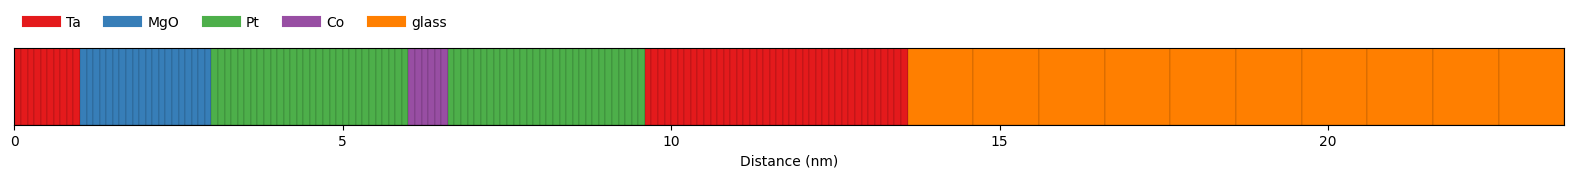

In [10]:
S.visualize()

## Initialize Heat and the Excitation

In [11]:
h = ud.Heat(S, True)

h.save_data = False
h.disp_messages = True

# enable heat diffusion
h.heat_diffusion = True
# set the boundary conditions
h.boundary_conditions = {'top_type': 'isolator', 'bottom_type': 'isolator'}

In [12]:
# spatial grid
_, _, distances = S.get_distances_of_layers()
# select only Co and Pt layers for plotting
select = np.concat((S.get_all_positions_per_unique_layer()['Co'], S.get_all_positions_per_unique_layer()['Pt']))
delays = np.r_[-2.5:10:0.01]*u.ps

fluence = 3.5  # in mJ/cm²

### Criticallity of Spin Heat Capacity

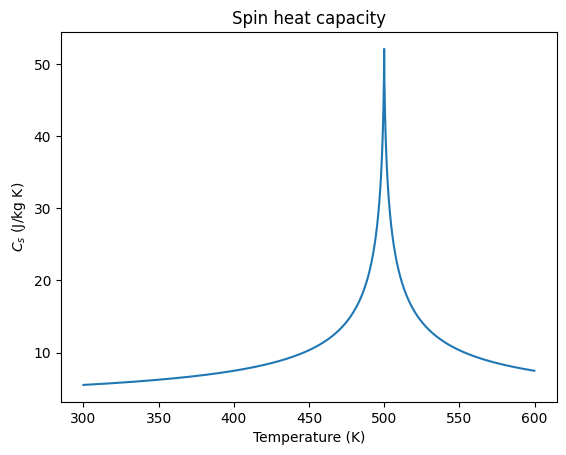

In [13]:
temps = np.r_[300:600:0.1]

plt.figure()
plt.plot(temps, layer_Co.heat_capacity[2](temps))
plt.xlabel('Temperature (K)')
plt.ylabel('$C_s$ (J/kg K)')
plt.title('Spin heat capacity')
plt.show()

## Absorption profile

Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


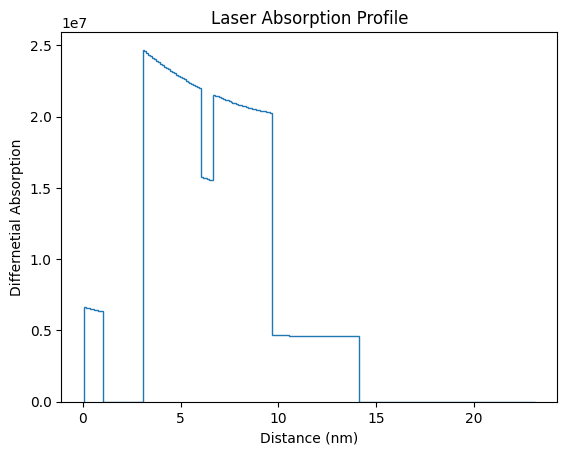

In [14]:
plt.figure()
dAdz, _, _, _ = h.get_multilayers_absorption_profile()
plt.stairs(dAdz[:-1], distances.to('nm'))
plt.xlabel('Distance (nm)')
plt.ylabel('Differnetial Absorption')
plt.title('Laser Absorption Profile')
plt.show()

## Single-Pulse Excitation

### 100-fs-Pulse

In [15]:
h.excitation = {'fluence': [fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [0.1/2.355]*u.ps,  # from FWHM to sigma
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_100fs, delta_temp_100fs = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 29.174119 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 32.456030 s
Elapsed time for _temp_map_: 61.733104 s


### 3-ps-Pulse

In [16]:
h.excitation = {'fluence': [fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [3.0/2.355]*u.ps,  # from FWHM to sigma
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_3ps, delta_temp_3ps = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 25.596356 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 8.841166 s
Elapsed time for _temp_map_: 34.568653 s


### Comparison of Spin temperatures

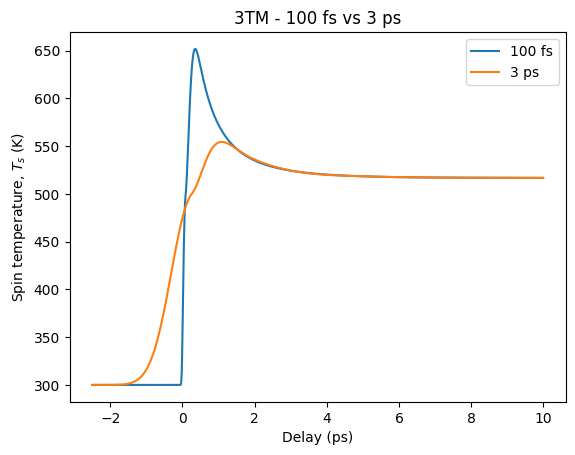

In [17]:
plt.figure()
plt.plot(delays.to('ps'), np.mean(temp_map_100fs[:, select, 2], 1), label='100 fs')
plt.plot(delays.to('ps'), np.mean(temp_map_3ps[:, select, 2], 1), label='3 ps')
plt.ylabel('Spin temperature, $T_s$ (K)')
plt.xlabel('Delay (ps)')
plt.legend()
plt.title('3TM - 100 fs vs 3 ps')
plt.show()

## Double Pulse Excitation

:::{hint}
Multipluse excitation is readily available by the providing lists of `fluence`, `delay_pump`, and `pulse_width` of the `excitation` dictionary.
:::

### 100 fs + 3 ps

In [18]:
h.excitation = {'fluence': [fluence, fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0, 4]*u.ps,
                'pulse_width':  [0.1, 3]*u.ps/2.355,
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_100fs_3ps, delta_temp_100fs_3ps = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:2 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 14.132894 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 26.430818 s
Calculating _heat_diffusion_ for excitation 2:2 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 20.259503 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 8.812536 s
Elapsed time for _temp_map_: 69.786765 s


### 3 ps + 100 fs

In [19]:
h.excitation = {'fluence': [fluence, fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0, 4]*u.ps,
                'pulse_width':  [3, 0.1]*u.ps/2.355,
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_3ps_100fs, delta_temp_3ps_100fs = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:2 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 32.957248 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 1.723398 s
Calculating _heat_diffusion_ for excitation 2:2 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 21.719136 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 26.382524 s
Elapsed time for _temp_map_: 82.972926 s


### Comparison

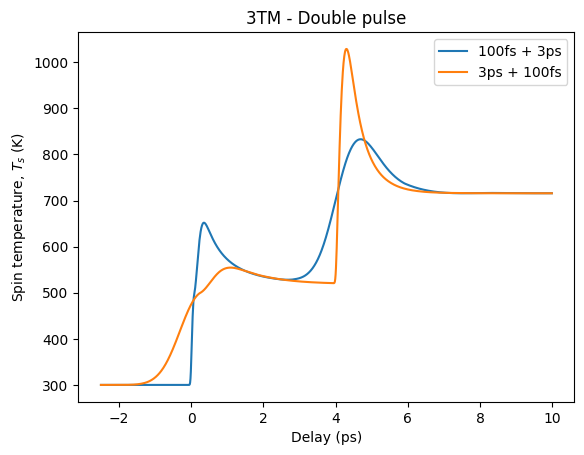

In [20]:
plt.figure()
plt.plot(delays.to('ps'), np.mean(temp_map_100fs_3ps[:, select, 2], 1), label='100fs + 3ps')
plt.plot(delays.to('ps'), np.mean(temp_map_3ps_100fs[:, select, 2], 1), label='3ps + 100fs')
plt.ylabel('Spin temperature, $T_s$ (K)')
plt.xlabel('Delay (ps)')
plt.legend()
plt.title('3TM - Double pulse')
plt.show()

## Effect of Criticality

In [21]:
layer_Co.heat_capacity = [f'{gamma:f}*T',
                          f'(2.98e6 + 1.5e3*(T-300))/{density_effective.magnitude:f}',
                          f'{C_s0:f}'
                          ]

layer_Pt.heat_capacity = [f'{gamma:f}*T',
                          f'(2.98e6 + 1.5e3*(T-300))/{density_effective.magnitude:f}',
                          f'{C_s0:f}'
                          ]

In [22]:
h.excitation = {'fluence': [fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [0.1/2.355]*u.ps,  # from FWHM to sigma
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_100fs_wo_crit, delta_temp_100fs_wo_crit = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 13.192575 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 28.466990 s
Elapsed time for _temp_map_: 41.793093 s


In [23]:
h.excitation = {'fluence': [fluence]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [3.0/2.355]*u.ps,  # from FWHM to sigma
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 90*u.deg}

temp_map_3ps_wo_crit, delta_temp_3ps_wo_crit = h.get_temp_map(delays, 300)

Surface incidence fluence scaled by factor 1.0000 due to incidence angle theta=90.00 deg
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 55.5 % and transmission of 27.9 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 14.999972 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 3.662041 s
Elapsed time for _temp_map_: 18.780535 s


### Comparison

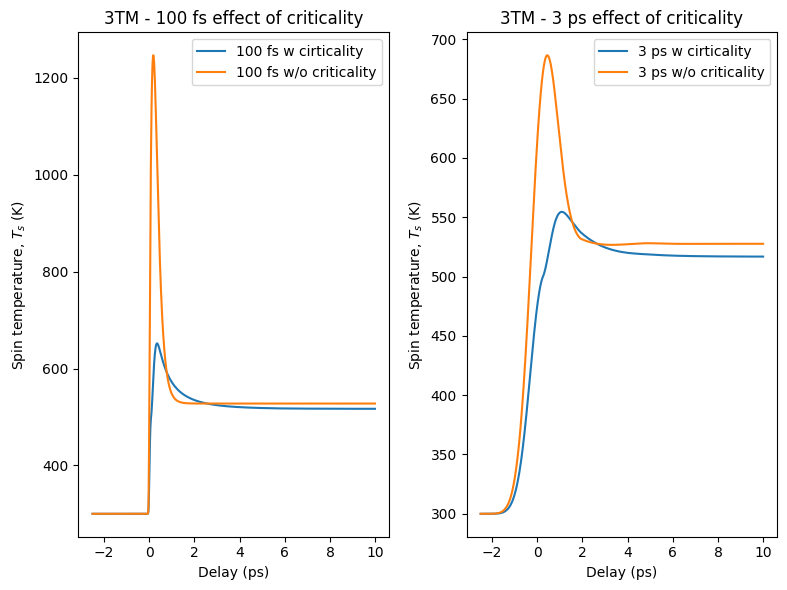

In [24]:
plt.figure(figsize=[8, 6])
plt.subplot(1, 2, 1)
plt.plot(delays.to('ps'), np.mean(temp_map_100fs[:, select, 2], 1), label='100 fs w cirticality')
plt.plot(delays.to('ps'), np.mean(temp_map_100fs_wo_crit[:, select, 2], 1), label='100 fs w/o criticality')
plt.ylabel('Spin temperature, $T_s$ (K)')
plt.xlabel('Delay (ps)')
plt.legend()
plt.title('3TM - 100 fs effect of criticality')

plt.subplot(1, 2, 2)
plt.plot(delays.to('ps'), np.mean(temp_map_3ps[:, select, 2], 1), label='3 ps w cirticality')
plt.plot(delays.to('ps'), np.mean(temp_map_3ps_wo_crit[:, select, 2], 1), label='3 ps w/o criticality')
plt.ylabel('Spin temperature, $T_s$ (K)')
plt.xlabel('Delay (ps)')
plt.legend()
plt.title('3TM - 3 ps effect of criticality')

plt.tight_layout()
plt.show()